# Finger EMG

## Load Data Session

### Load the CSV Files
`emg.csv`:
- timestamp, emg_channel_1, emg_channel_2, emg_channel_3, emg_channel_4, emg_channel_5, emg_channel_6, emg_channel_7, emg_channel_8

`fingers.csv`:
- timestamp, landmark_0_x, landmark_0_y, landmark_0_z, landmark_1_x, landmark_1_y, landmark_1_z, landmark_2_x, landmark_2_y, landmark_2_z, landmark_3_x, landmark_3_y, landmark_3_z, landmark_4_x, landmark_4_y, landmark_4_z, landmark_5_x, landmark_5_y, landmark_5_z, landmark_6_x, landmark_6_y, landmark_6_z, landmark_7_x, landmark_7_y, landmark_7_z, landmark_8_x, landmark_8_y, landmark_8_z, landmark_9_x, landmark_9_y, landmark_9_z, landmark_10_x, landmark_10_y, landmark_10_z, landmark_11_x, landmark_11_y, landmark_11_z, landmark_12_x, landmark_12_y, landmark_12_z, landmark_13_x, landmark_13_y, landmark_13_z, landmark_14_x, landmark_14_y, landmark_14_z, landmark_15_x, landmark_15_y, landmark_15_z, landmark_16_x, landmark_16_y, landmark_16_z, landmark_17_x, landmark_17_y, landmark_17_z, landmark_18_x, landmark_18_y, landmark_18_z, landmark_19_x, landmark_19_y, landmark_19_z, landmark_20_x, landmark_20_y, landmark_20_z

In [1]:
# emg.csv:
# timestamp,emg_channel_1,emg_channel_2,emg_channel_3,emg_channel_4,emg_channel_5,emg_channel_6,emg_channel_7,emg_channel_8

# finger_angles.csv:
# timestamp,THUMB,INDEX,MIDDLE,RING,PINKY
import os
import pandas as pd
from FingerDataProcess import FingerDataProcessor
from IPython.display import clear_output

def load_data(data_folder):
    """Loads EMG and finger angle data from a given session folder."""
    emg_path = os.path.join(data_folder, "emg.csv")
    finger_path = os.path.join(data_folder, "fingers.csv")
    emg_data = pd.read_csv(emg_path)
    
    processor = FingerDataProcessor()
    finger_angles = processor.load_and_process_csv(finger_path)
    
    # Change the timestamps to TimeDelta objects
    emg_data["timestamp"] = pd.to_timedelta(emg_data["timestamp"], unit="s")
    finger_angles["timestamp"] = pd.to_timedelta(finger_angles["timestamp"], unit="s")
    
    # Set the timestamps as the index
    emg_data.set_index("timestamp", inplace=True)
    finger_angles.set_index("timestamp", inplace=True)
    
    # Print the data folder and the number of rows with NaN values
    # print(data_folder)
    # emg_nan_rows = emg_data.isna().sum(axis=1).gt(0).sum()
    # emg_total_rows = len(emg_data)
    # print("EMG NaN rows:", emg_nan_rows, "({:.2f}%)".format(emg_nan_rows / emg_total_rows * 100))
    # finger_nan_rows = finger_angles.isna().sum(axis=1).gt(0).sum()
    # finger_total_rows = len(finger_angles)
    # print("Finger NaN rows:", finger_nan_rows, "({:.2f}%)".format(finger_nan_rows / finger_total_rows * 100))

    return emg_data, finger_angles

def load_session(session_folder):
    """Loads all sessions in a given data folder."""
    data_folders = [os.path.join(session_folder, folder) for folder in os.listdir(session_folder) if os.path.isdir(os.path.join(session_folder, folder))]
    session_data = [load_data(folder) for folder in data_folders]
    return session_data

ORIGINAL_EMG_FS = 250
ORIGINAL_FINGER_FS = 120

# Load all sessions in the data/ directory
data_folder = "../data_session_2"
session_data = load_session(data_folder)
# Clear the output Jupyter cell
clear_output()
# Print the number of loaded sessions
print("Loaded", len(session_data), "sessions.")

Loaded 20 sessions.


### Count the NaN values

In [2]:
# Print the percentage of NaN values in each session

# Calculate the percentage of NaN values in each session
nan_percentages = []
for emg_data, finger_data in session_data:
    emg_nan_rows = emg_data.isna().sum(axis=1).gt(0).sum()
    emg_total_rows = len(emg_data)
    emg_nan_percentage = emg_nan_rows / emg_total_rows * 100
    finger_nan_rows = finger_data.isna().sum(axis=1).gt(0).sum()
    finger_total_rows = len(finger_data)
    finger_nan_percentage = finger_nan_rows / finger_total_rows * 100
    nan_percentages.append((emg_nan_percentage, finger_nan_percentage))

total_emg_nan_percentage = sum(percentages[0] for percentages in nan_percentages) / len(nan_percentages)
total_finger_nan_percentage = sum(percentages[1] for percentages in nan_percentages) / len(nan_percentages)

# Print the results
print("Percentage of NaN values in each session:")
for i, percentages in enumerate(nan_percentages):
    print(f"Session {i + 1}: EMG {percentages[0]:.2f}%, Finger {percentages[1]:.2f}%")
print(f"Total: EMG {total_emg_nan_percentage:.2f}%, Finger {total_finger_nan_percentage:.2f}%")

Percentage of NaN values in each session:
Session 1: EMG 0.00%, Finger 34.78%
Session 2: EMG 0.00%, Finger 28.74%
Session 3: EMG 0.00%, Finger 4.05%
Session 4: EMG 0.00%, Finger 14.09%
Session 5: EMG 0.00%, Finger 16.36%
Session 6: EMG 0.00%, Finger 1.98%
Session 7: EMG 0.00%, Finger 20.47%
Session 8: EMG 0.00%, Finger 5.24%
Session 9: EMG 0.00%, Finger 2.91%
Session 10: EMG 0.00%, Finger 5.40%
Session 11: EMG 0.00%, Finger 17.09%
Session 12: EMG 0.00%, Finger 16.98%
Session 13: EMG 0.00%, Finger 16.43%
Session 14: EMG 0.00%, Finger 19.26%
Session 15: EMG 0.00%, Finger 12.31%
Session 16: EMG 0.00%, Finger 8.57%
Session 17: EMG 0.00%, Finger 9.86%
Session 18: EMG 0.00%, Finger 24.13%
Session 19: EMG 0.00%, Finger 13.28%
Session 20: EMG 0.00%, Finger 5.67%
Total: EMG 0.00%, Finger 13.88%


### Graph the Raw EMG Data

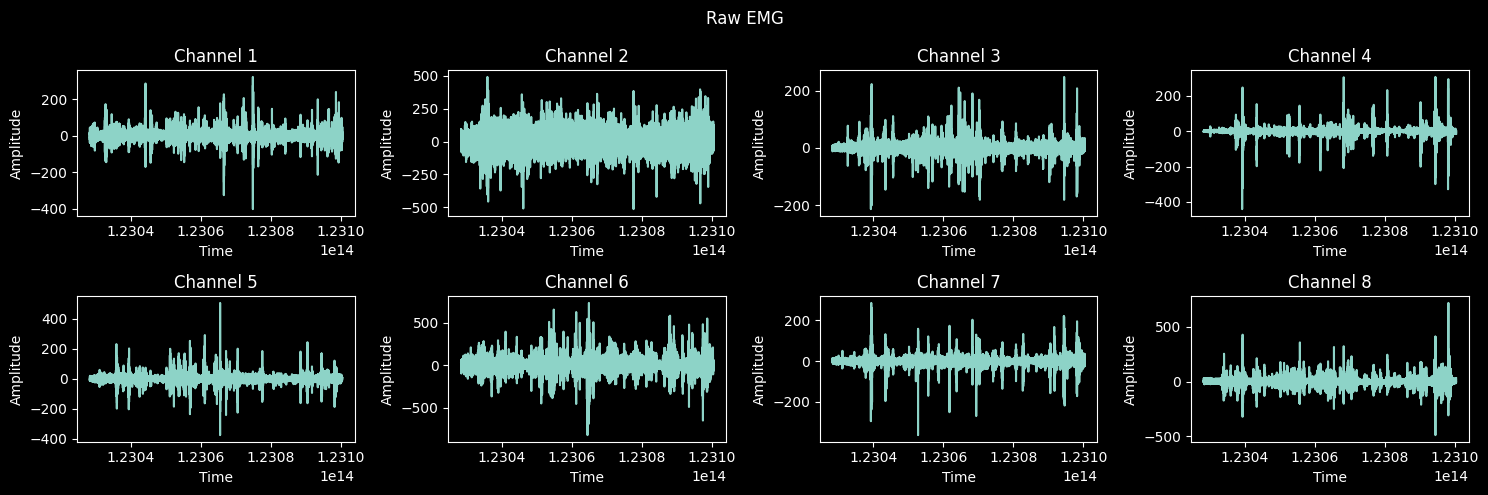

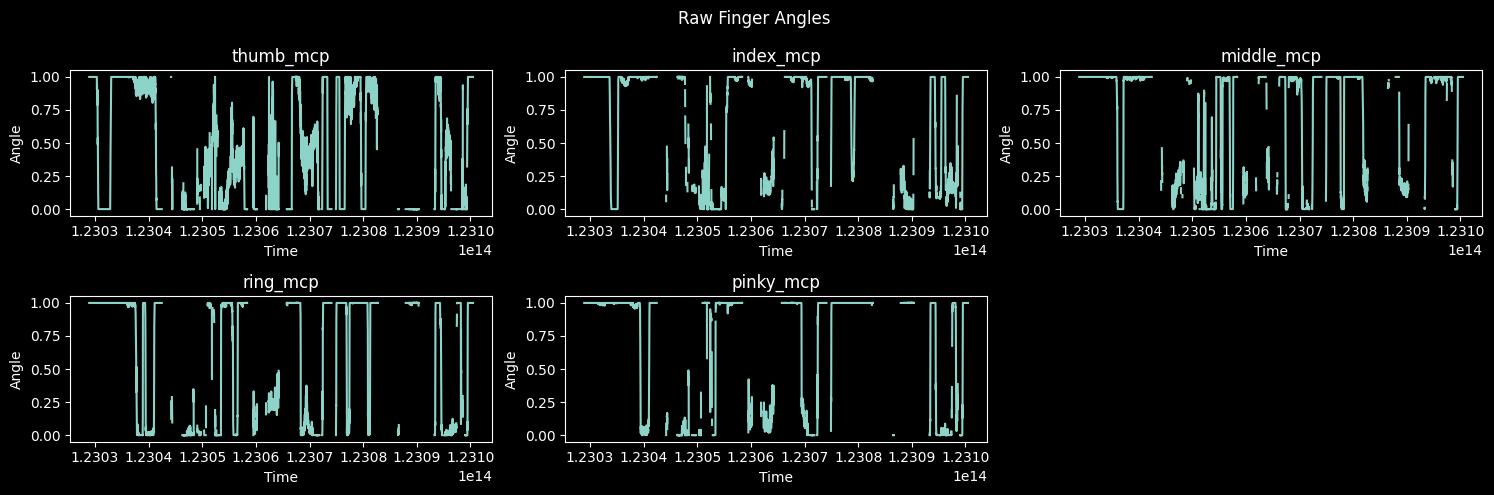

In [6]:
import matplotlib.pyplot as plt
    
def graph_emg(emg_data, emg_columns=None, title="EMG"):
    """Graphs the EMG data for all channels in a 2x4 grid."""
    # If no columns are specified, use all columns except the timestamp
    if emg_columns is None:
        emg_columns = emg_data.columns
    
    # Plot a 2 x 4 grid of EMG data
    plt.figure(figsize=(15, 5))
    plt.suptitle(title)
    for i, channel_name in enumerate(emg_columns):
        plt.subplot(2, 4, i + 1)
        plt.plot(emg_data[channel_name], label=f"Channel {i + 1}")
        plt.title(f"Channel {i + 1}")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

def graph_finger(finger_data, finger_columns=None, title="Finger Angles"):
    """Graphs the finger angle data for all fingers in a 2x3 grid."""
    # If no columns are specified, use all columns except the timestamp
    if finger_columns is None:
        finger_columns = finger_data.columns
    
    # Plot a 2 x 3 grid of finger data
    plt.figure(figsize=(15, 5))
    plt.suptitle(title)
    for i, finger_name in enumerate(finger_columns):
        plt.subplot(2, 3, i + 1)
        plt.plot(finger_data[finger_name], label=f"{finger_name}")
        plt.title(f"{finger_name}")
        plt.xlabel("Time")
        plt.ylabel("Angle")
    plt.tight_layout()
    plt.show()

# Graph the first subsession
graph_emg(session_data[0][0], title="Raw EMG")
graph_finger(session_data[0][1], title="Raw Finger Angles")

## Preprocess Data

### Rectifying EMG Data, Low-Pass Filter, Resampling, and Handling Missing Data

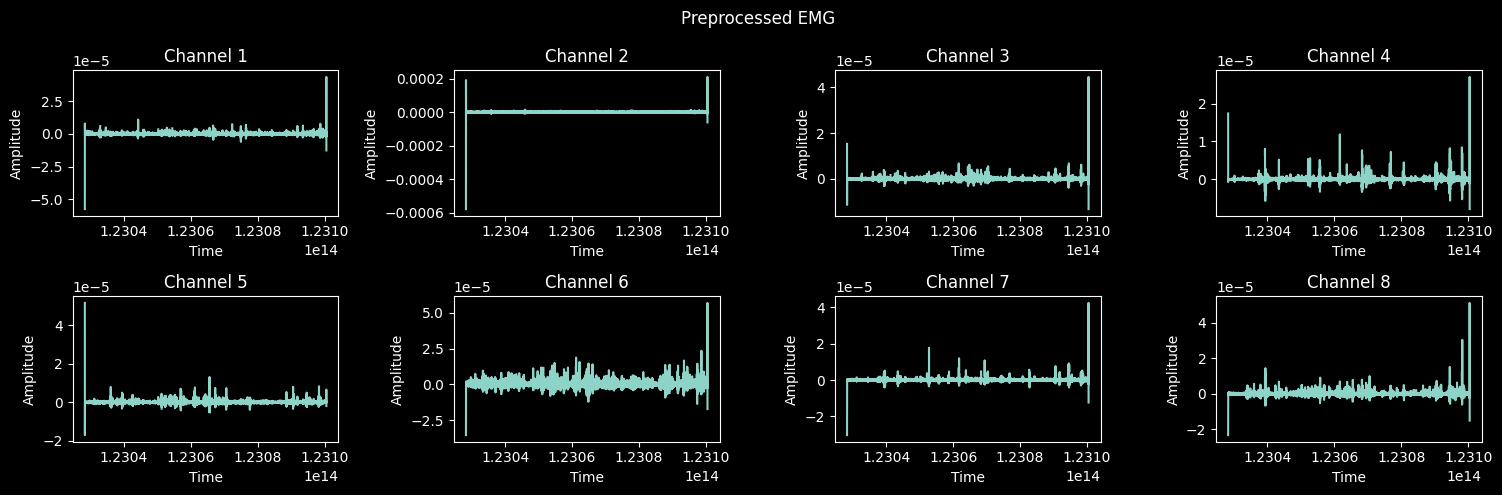

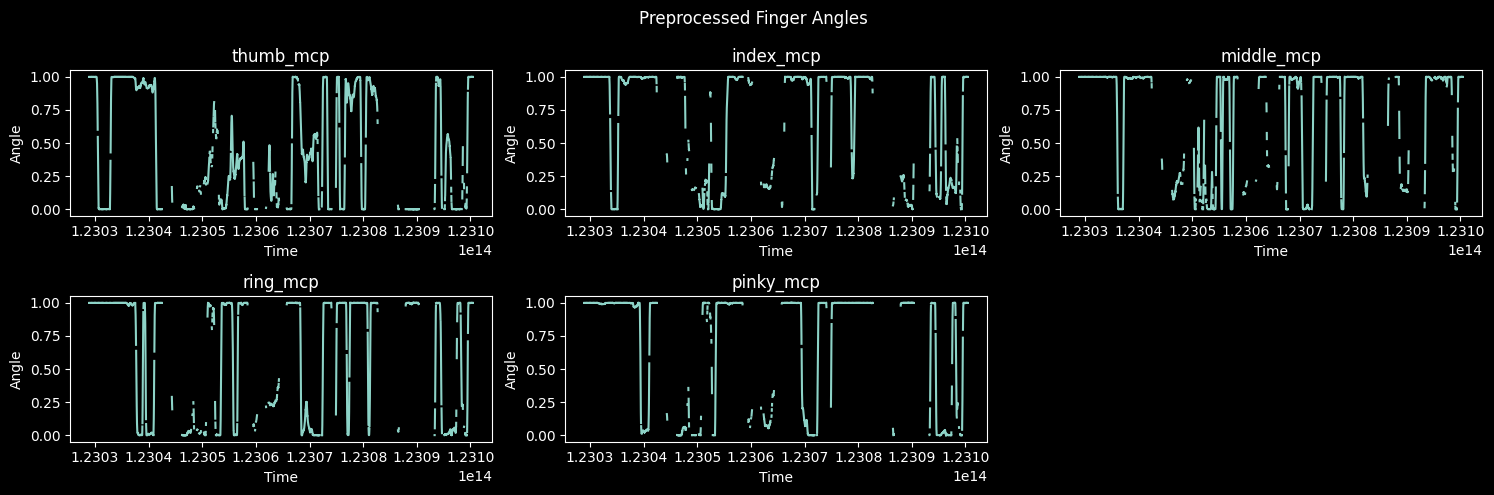

In [ ]:
from scipy.signal import butter, filtfilt, resample
import matplotlib.pyplot as plt

def low_pass_filter(data, cutoff=4, fs=250, order=2):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

def high_pass_filter(data, cutoff=20, fs=250, order=2):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return filtfilt(b, a, data)

def preprocess_emg(emg_data, original_fs, new_fs=100, lp_cutoff=4):
    """Preprocesses the EMG data by filtering and resampling."""
    emg_data_filtered = emg_data.copy()
    # Rectify the EMG data
    emg_data_filtered = emg_data.abs()
    # Apply a low-pass filter to the EMG data
    for column in emg_data.columns:
        emg_data_filtered[column] = low_pass_filter(emg_data_filtered[column], cutoff=lp_cutoff, fs=original_fs)
    
    # Apply a high-pass filter to the EMG data
    for column in emg_data.columns:
        emg_data_filtered[column] = high_pass_filter(emg_data_filtered[column], cutoff=20, fs=original_fs)
    
    # Resample the EMG data to the new sampling rate
    resampled_data = emg_data_filtered.resample(f"{int(1000 / new_fs)}ms").mean()
    
    return resampled_data
    
def moving_average(data, window_size=5):
    return data.rolling(window=window_size, min_periods=1).mean()

def preprocess_finger(finger_data, original_fs, new_fs=100, lp_cutoff=3, ma_window_size=5):
    """Preprocesses the finger angle data by filtering, smoothing, and resampling."""
    # Create NaN mask
    nan_mask = finger_data.isna()
    # Interpolate missing values
    finger_data = finger_data.interpolate()

    # Apply a low-pass filter to the finger angle data
    finger_data_filtered = finger_data.copy()
    for column in finger_data.columns:
        finger_data_filtered[column] = low_pass_filter(finger_data[column], cutoff=lp_cutoff, fs=original_fs)
    
    # Apply moving average smoothing
    finger_data_smoothed = finger_data_filtered.apply(lambda x: moving_average(x, window_size=ma_window_size))
    
    # Resample the finger angle data to the new sampling rate
    resampled_data = finger_data_smoothed.resample(f"{int(1000 / new_fs)}ms").mean()
    resampled_nan_mask = nan_mask.resample(f"{int(1000 / new_fs)}ms").mean() > 0.5
    resampled_data[resampled_nan_mask] = None
    
    # Clip the finger angle data to the valid range
    resampled_data = resampled_data.clip(0, 1)
    
    return resampled_data

def preprocess_session(session_data, new_fs=100):
    """Preprocesses the EMG and finger angle data for entire session."""
    session_data = session_data.copy()
    
    for i, (emg_data, finger_data) in enumerate(session_data):
        session_data[i] = (preprocess_emg(emg_data, ORIGINAL_EMG_FS, new_fs), preprocess_finger(finger_data, ORIGINAL_FINGER_FS, new_fs))
        
    return session_data

# Preprocess the session data
CURRENT_FS = 100
preprocessed_session_data = preprocess_session(session_data, new_fs=CURRENT_FS)

graph_emg(preprocessed_session_data[0][0], title="Preprocessed EMG")
graph_finger(preprocessed_session_data[0][1], title="Preprocessed Finger Angles")

### Normalize EMG Data

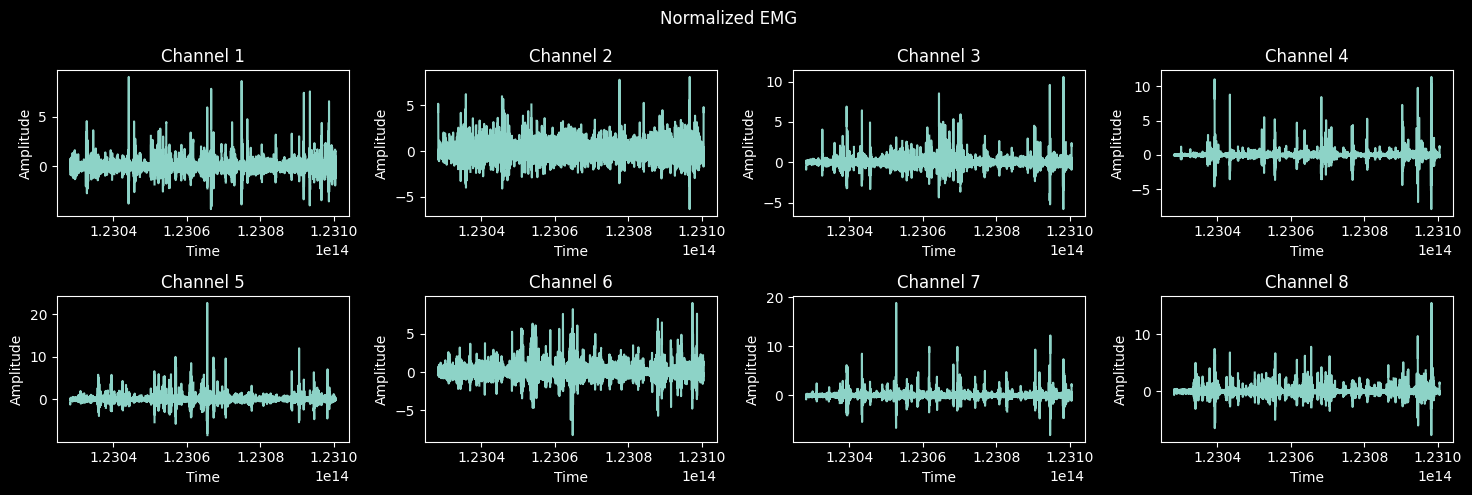

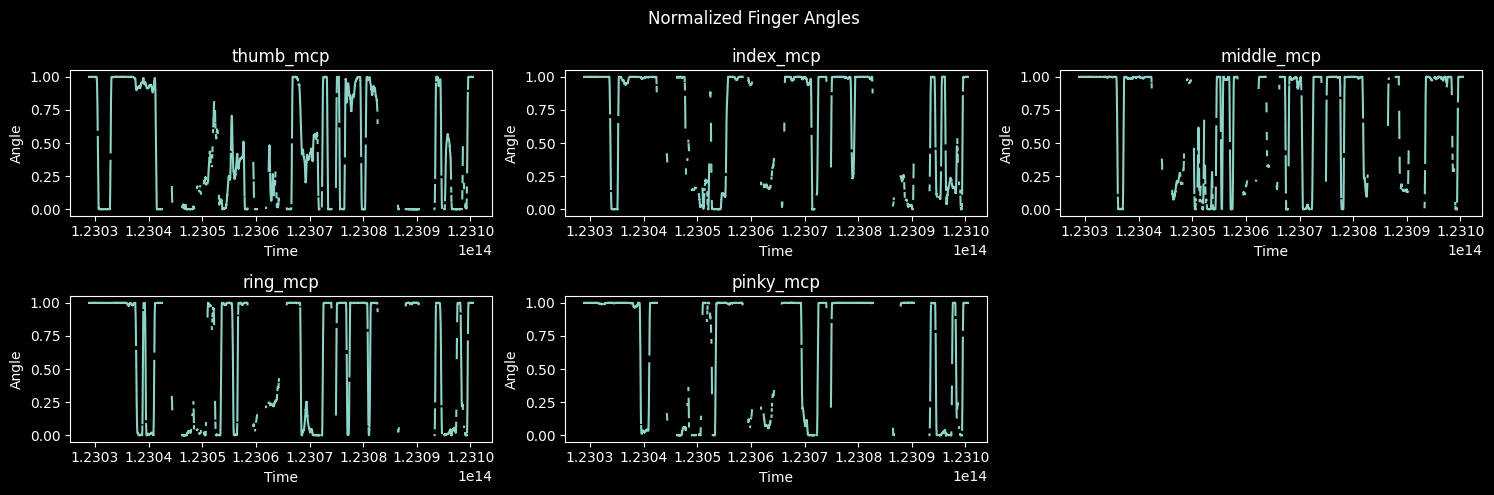

In [69]:
def calculate_session_mean_std(session_data):
    mean_sum = 0
    std_sum = 0
    
    for emg_data, _ in session_data:
        emg_mean = emg_data.mean()
        emg_std = emg_data.std()
        
        mean_sum += emg_mean
        std_sum += emg_std
        
    mean = mean_sum / len(session_data)
    std = std_sum / len(session_data)
    
    return mean, std
    
def normalize_session(session_data):
    mean, std = calculate_session_mean_std(session_data)
    normalized_session_data = []
    
    for emg_data, finger_data in session_data:
        normalized_emg_data = (emg_data - mean) / std
        normalized_session_data.append((normalized_emg_data, finger_data))
        
    return normalized_session_data, mean, std

normalized_session_data, mean, std = normalize_session(preprocessed_session_data)

graph_emg(normalized_session_data[0][0], title="Normalized EMG")
graph_finger(normalized_session_data[0][1], title="Normalized Finger Angles")